# Regressão Softmax com dados do MNIST

## Objetivo

O objetivo deste notebook é ilustrar o uso de praticamente a mesma rede desenvolvida para a classificação das flores Íris, porém agora com o problema de classificação de dígitos manuscritos utilizando o dataset MNIST.
As principais diferenças são:
- tipo do dado, agora imagem com muito atributos: 28 x 28 pixels
- número de amostras, muito maior, 60 mil
Neste exercício será possível a interpretação do significado dos parâmetros treinados

## Importação das bibliotecas

In [2]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import torch
from torch.autograd import Variable

import torchvision

## Carregamento dos dados do MNIST

In [3]:
! git clone https://github.com/vcasadei/MNIST.git

Cloning into 'MNIST'...
remote: Enumerating objects: 10, done.
remote: Total 10 (delta 0), reused 0 (delta 0), pack-reused 10 (from 1)
Receiving objects: 100% (10/10), 11.01 MiB | 16.04 MiB/s, done.
Resolving deltas: 100% (2/2), done.


In [4]:
!ls MNIST

processed  raw


In [5]:
dataset_dir = 'MNIST/'

x_train, y_train = torch.load(dataset_dir + 'processed/training.pt')

print("Amostras de treinamento:", x_train.size(0))

print("\nDimensões dos dados das imagens:   ", x_train.size())
print("Valores mínimo e máximo dos pixels:", torch.min(x_train), torch.max(x_train))
print("Tipo dos dados das imagens:        ", type(x_train))
print("Tipo das classes das imagens:      ", type(y_train))

Amostras de treinamento: 60000

Dimensões dos dados das imagens:    torch.Size([60000, 28, 28])
Valores mínimo e máximo dos pixels: tensor(0, dtype=torch.uint8) tensor(255, dtype=torch.uint8)
Tipo dos dados das imagens:         <class 'torch.Tensor'>
Tipo das classes das imagens:       <class 'torch.Tensor'>


### Carregamento, normalização e seleção dos dados do MNIST

Neste exemplo utilizaremos apenas 1000 amostras de treinamento.

In [6]:
x_train = x_train.float()

x_train = x_train / 255.

if True:
    n_samples_train = 1000

    x_train = x_train[:n_samples_train]
    y_train = y_train[:n_samples_train]

print("Amostras de treinamento:", x_train.size(0))

print("\nDimensões dos dados das imagens:   ", x_train.size())
print("Valores mínimo e máximo dos pixels:", torch.min(x_train), torch.max(x_train))
print("Tipo dos dados das imagens:        ", type(x_train))
print("Tipo das classes das imagens:      ", type(y_train))

Amostras de treinamento: 1000

Dimensões dos dados das imagens:    torch.Size([1000, 28, 28])
Valores mínimo e máximo dos pixels: tensor(0.) tensor(1.)
Tipo dos dados das imagens:         <class 'torch.Tensor'>
Tipo das classes das imagens:       <class 'torch.Tensor'>


### Carregamento e normalização dos dados de validação

In [7]:
x_val, y_val = torch.load(dataset_dir + 'processed/test.pt')

x_val = x_val.float()
x_val = x_val / 255.

# Limit validation samples for consistency with training set, if needed
# If you want to use the full test set for validation, comment this block
if True:
    n_samples_val = 200 # Using a smaller validation set for demonstration

    x_val = x_val[:n_samples_val]
    y_val = y_val[:n_samples_val]

print("Amostras de validação:", x_val.size(0))

print("\nDimensões dos dados das imagens de validação:   ", x_val.size())
print("Valores mínimo e máximo dos pixels de validação:", torch.min(x_val), torch.max(x_val))
print("Tipo dos dados das imagens de validação:        ", type(x_val))
print("Tipo das classes das imagens de validação:      ", type(y_val))

Amostras de validação: 200

Dimensões dos dados das imagens de validação:    torch.Size([200, 28, 28])
Valores mínimo e máximo dos pixels de validação: tensor(0.) tensor(1.)
Tipo dos dados das imagens de validação:         <class 'torch.Tensor'>
Tipo das classes das imagens de validação:       <class 'torch.Tensor'>


### Visualizando os dados

(np.float64(-0.5), np.float64(232.5), np.float64(87.5), np.float64(-0.5))

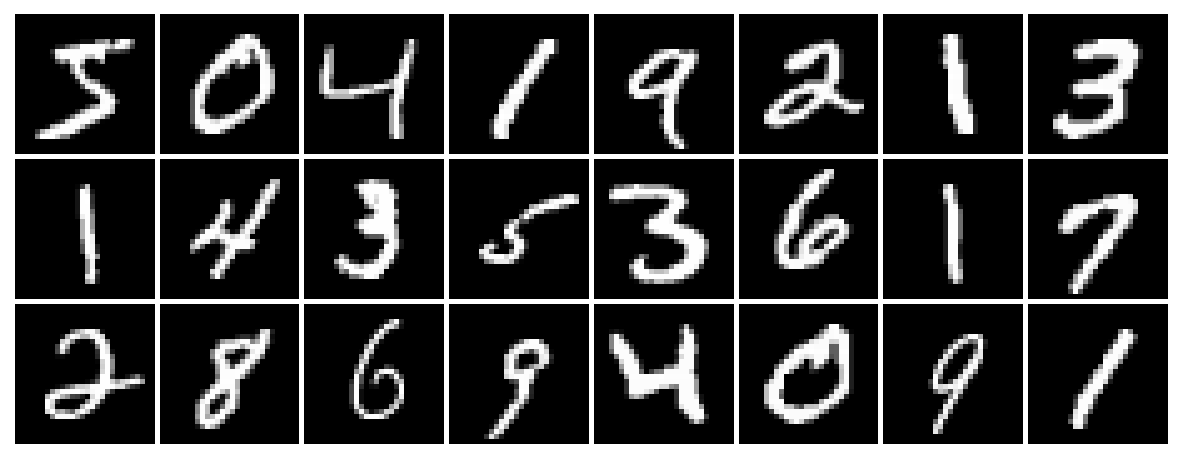

In [8]:
n_samples = 24

# cria um grid com as imagens
grid = torchvision.utils.make_grid(x_train[:n_samples].unsqueeze(dim=1), pad_value=1.0, padding=1)

plt.figure(figsize=(15, 10))
plt.imshow(grid.numpy().transpose(1, 2, 0))
plt.axis('off')

### Visualizando uma imagem com o matplotlib

class: tensor(5)


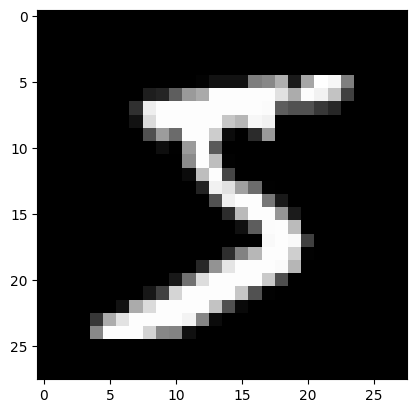

In [9]:
image  = x_train[0]
target = y_train[0]

plt.imshow(image.numpy(), cmap='gray')
print('class:', target)

## Modelo

In [10]:
model = torch.nn.Linear(28*28, 10) # 28*28 atributos de entrada e 10 neurônios na sáida

### Testando um predict com poucas amostras

In [11]:
pred = model(Variable(x_train[:5].view(-1,28*28)))
pred

tensor([[ 0.0051,  0.2794,  0.2541,  0.0652, -0.0095,  0.3531,  0.1610, -0.4409,
         -0.0122, -0.1512],
        [ 0.1877,  0.3337,  0.2378,  0.1098,  0.0245,  0.2389,  0.2901, -0.5833,
         -0.1779, -0.0078],
        [-0.1628,  0.1263,  0.1308,  0.0069,  0.1020,  0.2000,  0.0979, -0.1939,
         -0.1702, -0.0529],
        [-0.0941,  0.1541, -0.0034, -0.0052,  0.2751, -0.0566,  0.1892, -0.0459,
         -0.1201, -0.0542],
        [-0.1875,  0.3025,  0.3095, -0.0562, -0.0729,  0.3768,  0.1274, -0.0630,
         -0.2224, -0.2738]], grad_fn=<AddmmBackward0>)

In [12]:
xin = x_train[:5].view(-1,28*28)
score = model(Variable(xin))
score

tensor([[ 0.0051,  0.2794,  0.2541,  0.0652, -0.0095,  0.3531,  0.1610, -0.4409,
         -0.0122, -0.1512],
        [ 0.1877,  0.3337,  0.2378,  0.1098,  0.0245,  0.2389,  0.2901, -0.5833,
         -0.1779, -0.0078],
        [-0.1628,  0.1263,  0.1308,  0.0069,  0.1020,  0.2000,  0.0979, -0.1939,
         -0.1702, -0.0529],
        [-0.0941,  0.1541, -0.0034, -0.0052,  0.2751, -0.0566,  0.1892, -0.0459,
         -0.1201, -0.0542],
        [-0.1875,  0.3025,  0.3095, -0.0562, -0.0729,  0.3768,  0.1274, -0.0630,
         -0.2224, -0.2738]], grad_fn=<AddmmBackward0>)

In [13]:
import torch.nn.functional as F
prob = F.softmax(score, dim=1)
prob

tensor([[0.0934, 0.1229, 0.1198, 0.0992, 0.0920, 0.1322, 0.1091, 0.0598, 0.0918,
         0.0799],
        [0.1096, 0.1269, 0.1153, 0.1014, 0.0931, 0.1154, 0.1214, 0.0507, 0.0761,
         0.0902],
        [0.0835, 0.1115, 0.1120, 0.0989, 0.1088, 0.1200, 0.1084, 0.0809, 0.0829,
         0.0932],
        [0.0881, 0.1130, 0.0965, 0.0963, 0.1275, 0.0915, 0.1170, 0.0925, 0.0859,
         0.0917],
        [0.0789, 0.1287, 0.1296, 0.0899, 0.0884, 0.1386, 0.1080, 0.0893, 0.0762,
         0.0723]], grad_fn=<SoftmaxBackward0>)

## Treinamento

### Inicialização dos parâmetros

In [14]:
epochs = 100
learningRate = 0.5

# Utilizaremos CrossEntropyLoss como função de perda
criterion = torch.nn.CrossEntropyLoss()

# Gradiente descendente
optimizer = torch.optim.SGD(model.parameters(), lr=learningRate)

### Laço de treinamento dos pesos

In [15]:
import numpy
losses = []
zs = []

for i in range(epochs):
    # Transforma a entrada para uma dimensão
    inputs = Variable(x_train.view(-1, 28 * 28))
    # Predict da rede
    outputs = model(inputs)

    # z0 a z9
    zs.append(outputs[1].detach().numpy())

    # calcula a perda
    loss = criterion(outputs, Variable(y_train))

    # zero, backpropagation, ajusta parâmetros pelo gradiente descendente
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    losses.append(loss.item())

    _, predicts = torch.max(outputs, 1)

    y_pred = predicts.data
    accuracy = (y_pred.numpy() == y_train.numpy()).mean()


### Laço de treinamento dos pesos (com validação e armazenamento de métricas)

In [16]:
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

for i in range(epochs):
    # Passada de treinamento
    inputs_train = Variable(x_train.view(-1, 28 * 28))
    outputs_train = model(inputs_train)
    loss_train = criterion(outputs_train, Variable(y_train))

    # Zero, backpropagation, ajusta parâmetros pelo gradiente descendente
    optimizer.zero_grad()
    loss_train.backward()
    optimizer.step()

    train_losses.append(loss_train.item())

    _, predicts_train = torch.max(outputs_train, 1)
    accuracy_train = (predicts_train.data.numpy() == y_train.numpy()).mean()
    train_accuracies.append(accuracy_train)

    # Passada de validação
    with torch.no_grad(): # Desabilita o cálculo de gradientes para validação
        inputs_val = Variable(x_val.view(-1, 28 * 28))
        outputs_val = model(inputs_val)
        loss_val = criterion(outputs_val, Variable(y_val))
        val_losses.append(loss_val.item())

        _, predicts_val = torch.max(outputs_val, 1)
        accuracy_val = (predicts_val.data.numpy() == y_val.numpy()).mean()
        val_accuracies.append(accuracy_val)

    print(f'Epoch [{i+1}/{epochs}], ' \
          f'Train Loss: {loss_train.item():.4f}, ' \
          f'Train Acc: {accuracy_train:.4f}, ' \
          f'Val Loss: {loss_val.item():.4f}, ' \
          f'Val Acc: {accuracy_val:.4f}')

Epoch [1/100], Train Loss: 0.2637, Train Acc: 0.9400, Val Loss: 0.3904, Val Acc: 0.9000
Epoch [2/100], Train Loss: 0.2624, Train Acc: 0.9400, Val Loss: 0.3895, Val Acc: 0.9000
Epoch [3/100], Train Loss: 0.2611, Train Acc: 0.9400, Val Loss: 0.3886, Val Acc: 0.9000
Epoch [4/100], Train Loss: 0.2598, Train Acc: 0.9400, Val Loss: 0.3876, Val Acc: 0.9000
Epoch [5/100], Train Loss: 0.2586, Train Acc: 0.9400, Val Loss: 0.3867, Val Acc: 0.9000
Epoch [6/100], Train Loss: 0.2573, Train Acc: 0.9410, Val Loss: 0.3859, Val Acc: 0.9000
Epoch [7/100], Train Loss: 0.2561, Train Acc: 0.9410, Val Loss: 0.3850, Val Acc: 0.9000
Epoch [8/100], Train Loss: 0.2548, Train Acc: 0.9420, Val Loss: 0.3841, Val Acc: 0.9000
Epoch [9/100], Train Loss: 0.2536, Train Acc: 0.9420, Val Loss: 0.3833, Val Acc: 0.9000
Epoch [10/100], Train Loss: 0.2524, Train Acc: 0.9420, Val Loss: 0.3825, Val Acc: 0.9000
Epoch [11/100], Train Loss: 0.2512, Train Acc: 0.9430, Val Loss: 0.3817, Val Acc: 0.9000
Epoch [12/100], Train Loss: 0.

In [17]:
print('Final loss:', loss.item())

Final loss: 0.26504307985305786


### Visualizando gráfico de perda durante o treinamento

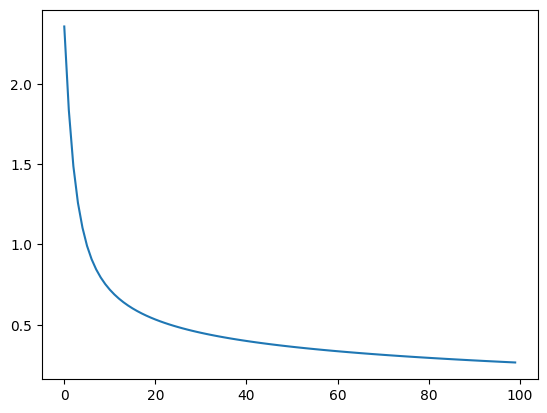

In [18]:
plt.plot(losses)

### Visualizando gráficos de perda e acurácia durante o treinamento

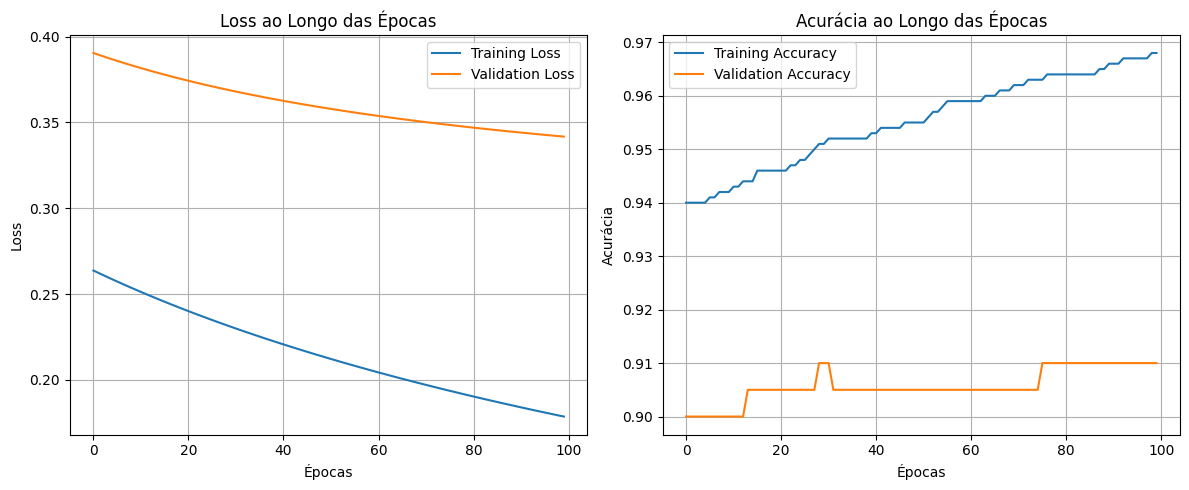

In [19]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title('Loss ao Longo das Épocas')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label='Training Accuracy')
plt.plot(val_accuracies, label='Validation Accuracy')
plt.title('Acurácia ao Longo das Épocas')
plt.xlabel('Épocas')
plt.ylabel('Acurácia')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## Avaliação

### Acurácia tanto no conjunto de treinamento como no conjunto de testes

In [20]:
def predict(model, input_data):
    outputs = model(Variable(input_data))
    _, predicts = torch.max(outputs, 1)

    return predicts.data

y_pred = predict(model, x_train.view(-1, 28*28))
accuracy = (y_pred.numpy() == y_train.numpy()).mean()
print('Accuracy:', accuracy)

Accuracy: 0.968


### Matriz de confusão com dados de treinamento e teste

In [21]:
print('Matriz de confusão:')
pd.crosstab(y_pred.numpy(), y_train.numpy())

Matriz de confusão:


col_0,0,1,2,3,4,5,6,7,8,9
row_0,,,,,,,,,,
0,97,0,1,0,0,0,0,0,0,2
1,0,112,1,0,0,0,0,2,1,0
2,0,0,92,2,0,1,0,1,0,0
3,0,0,0,90,0,1,0,0,0,0
4,0,0,0,0,104,1,0,1,0,1
5,0,2,0,1,0,87,0,0,1,1
6,0,0,1,0,0,1,94,0,0,0
7,0,0,1,0,0,0,0,113,0,2
8,0,1,2,0,0,0,0,0,85,0


## Visualizando a matriz de pesos treinados

Observe que a matriz de peso treinado para cada classe mostra a importância dos pesos associados aos caracteres de cada classe.

weights: torch.Size([10, 784])
bias:    torch.Size([10])


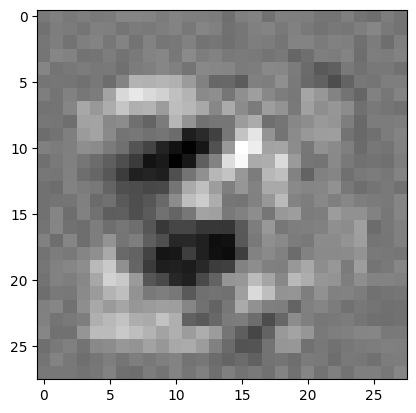

In [22]:
weights = model.state_dict()['weight']
print('weights:', weights.shape)

bias = model.state_dict()['bias']
print('bias:   ', bias.shape)

# Visualizando pesos da classe 3
plt.imshow(weights[3, :].numpy().reshape((28,28)),cmap = 'gray')
plt.show()

### Visualizando os pesos de todas as classes

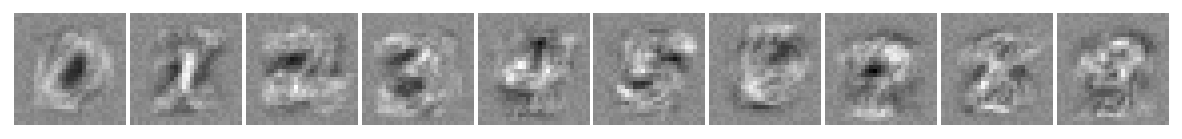

In [23]:
# cria um grid com as imagens
grid = torchvision.utils.make_grid(weights.view(-1, 1, 28, 28), normalize=True, pad_value=1.0, padding=1, nrow=10)

plt.figure(figsize=(15, 10))
plt.imshow(grid.numpy().transpose(1, 2, 0))
plt.axis('off');

### Diagrama da regressão softmax com visualização dos pesos W

![alt text](https://raw.githubusercontent.com/vcasadei/images/master/RegressaoSoftmaxArgmaxNMIST.png)

# Atividades

## Exercícios

- 1) Insira código no laço do treinamento para que no final de cada época,
     seja impresso: o número da época e a perda e a acurácia

In [24]:
losses = []
zs = []

for i in range(epochs):
    # Transforma a entrada para uma dimensão
    inputs = Variable(x_train.view(-1, 28 * 28))
    # Predict da rede
    outputs = model(inputs)

    # z0 a z9
    zs.append(outputs[1].detach().numpy())

    # calcula a perda
    loss = criterion(outputs, Variable(y_train))

    # zero, backpropagation, ajusta parâmetros pelo gradiente descendente
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    losses.append(loss.item())

    _, predicts = torch.max(outputs, 1)
    y_pred = predicts.data
    accuracy = (y_pred.numpy() == y_train.numpy()).mean()

    # Imprime época, perda e acurácia
    print('Epoch[{}/{}], loss: {:.6f}, acc: {:.6f}'
          .format(i+1, epochs, loss.data, accuracy))

Epoch[1/100], loss: 0.178049, acc: 0.968000
Epoch[2/100], loss: 0.177477, acc: 0.968000
Epoch[3/100], loss: 0.176909, acc: 0.968000
Epoch[4/100], loss: 0.176344, acc: 0.968000
Epoch[5/100], loss: 0.175782, acc: 0.968000
Epoch[6/100], loss: 0.175224, acc: 0.968000
Epoch[7/100], loss: 0.174669, acc: 0.968000
Epoch[8/100], loss: 0.174117, acc: 0.968000
Epoch[9/100], loss: 0.173569, acc: 0.968000
Epoch[10/100], loss: 0.173024, acc: 0.968000
Epoch[11/100], loss: 0.172482, acc: 0.969000
Epoch[12/100], loss: 0.171944, acc: 0.969000
Epoch[13/100], loss: 0.171409, acc: 0.969000
Epoch[14/100], loss: 0.170877, acc: 0.969000
Epoch[15/100], loss: 0.170348, acc: 0.969000
Epoch[16/100], loss: 0.169822, acc: 0.969000
Epoch[17/100], loss: 0.169299, acc: 0.969000
Epoch[18/100], loss: 0.168779, acc: 0.969000
Epoch[19/100], loss: 0.168262, acc: 0.969000
Epoch[20/100], loss: 0.167748, acc: 0.969000
Epoch[21/100], loss: 0.167238, acc: 0.969000
Epoch[22/100], loss: 0.166730, acc: 0.969000
Epoch[23/100], loss

- 2) Insira código no laço do treinamento para visualização dos valores dos gradientes referentes à classe do dígito 4, no final de cada época.

Epoch[1/100], loss: 0.106419, acc: 0.991000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


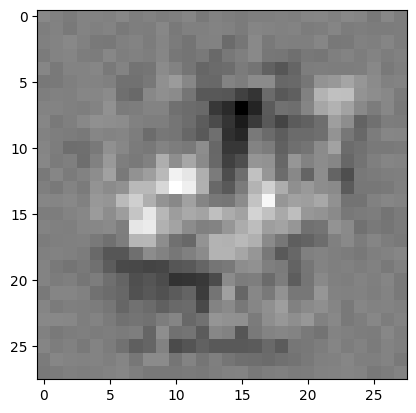

Epoch[2/100], loss: 0.106195, acc: 0.991000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


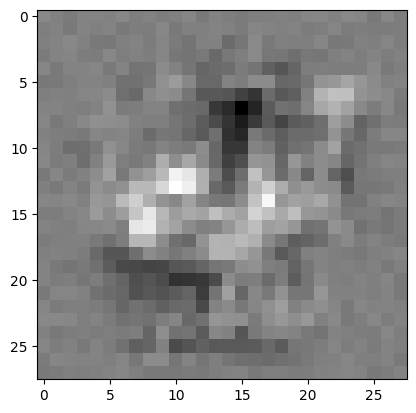

Epoch[3/100], loss: 0.105973, acc: 0.991000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


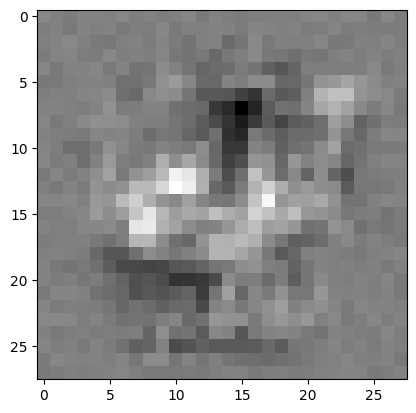

Epoch[4/100], loss: 0.105751, acc: 0.991000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


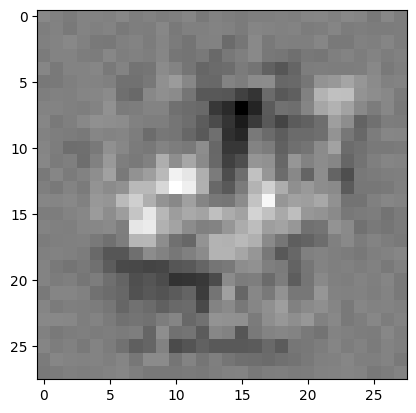

Epoch[5/100], loss: 0.105530, acc: 0.991000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


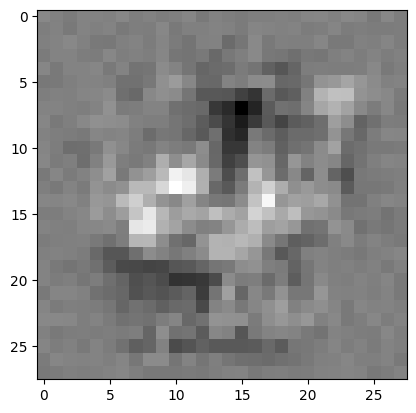

Epoch[6/100], loss: 0.105310, acc: 0.991000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


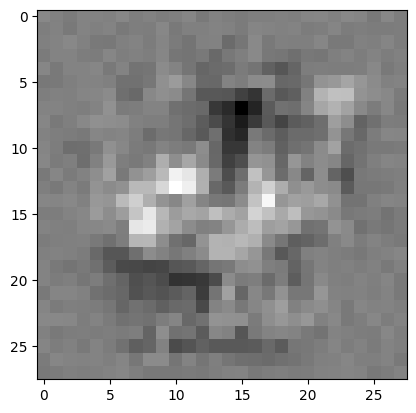

Epoch[7/100], loss: 0.105090, acc: 0.991000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


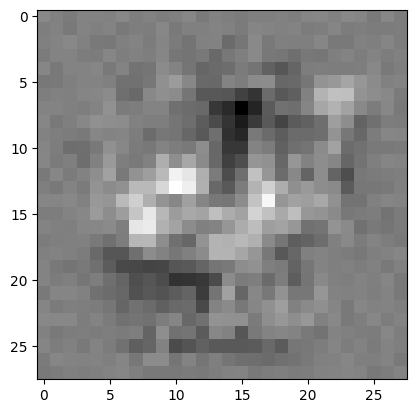

Epoch[8/100], loss: 0.104872, acc: 0.991000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


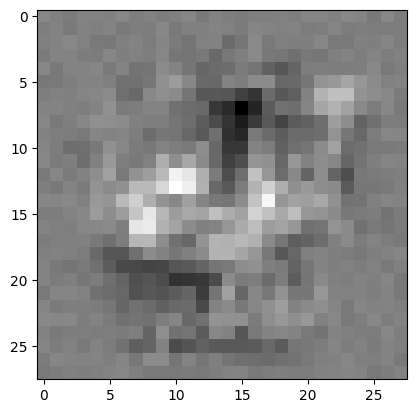

Epoch[9/100], loss: 0.104654, acc: 0.991000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


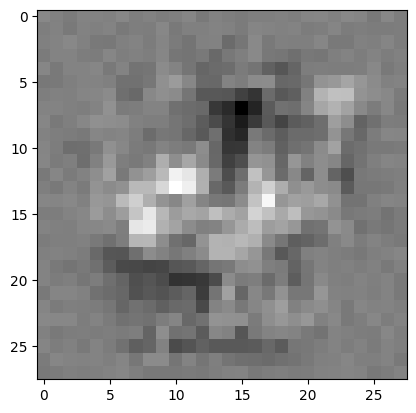

Epoch[10/100], loss: 0.104437, acc: 0.991000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


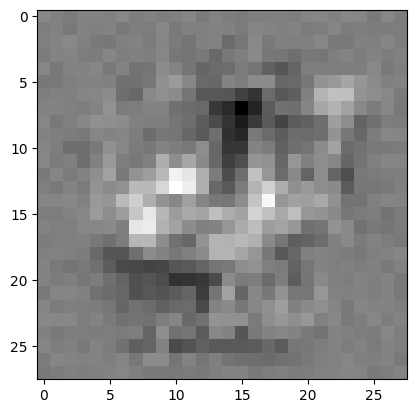

Epoch[11/100], loss: 0.104221, acc: 0.991000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


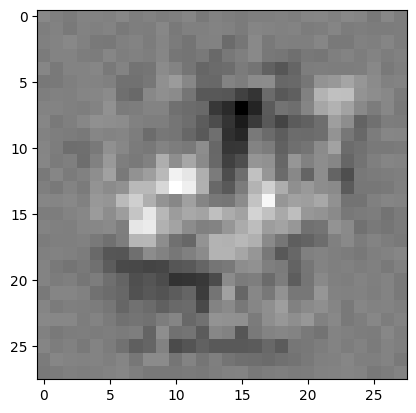

Epoch[12/100], loss: 0.104006, acc: 0.991000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


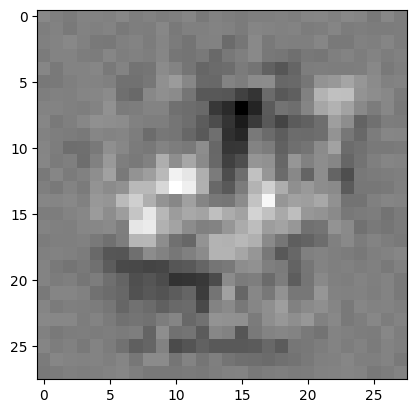

Epoch[13/100], loss: 0.103791, acc: 0.991000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


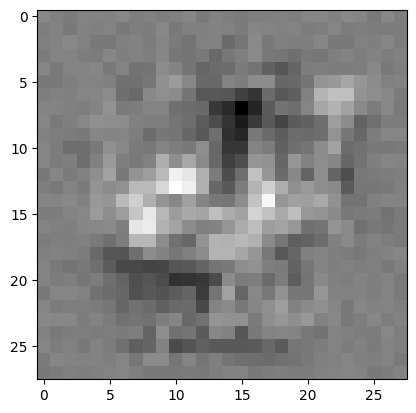

Epoch[14/100], loss: 0.103577, acc: 0.992000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


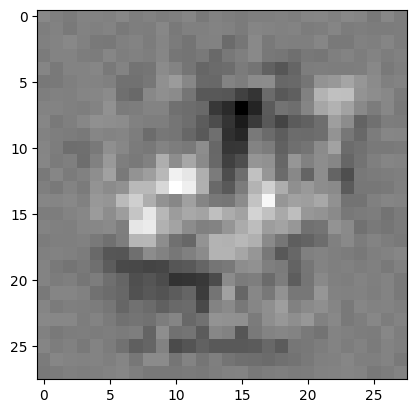

Epoch[15/100], loss: 0.103364, acc: 0.992000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


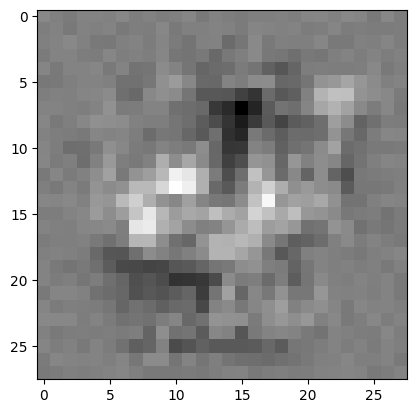

Epoch[16/100], loss: 0.103152, acc: 0.992000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


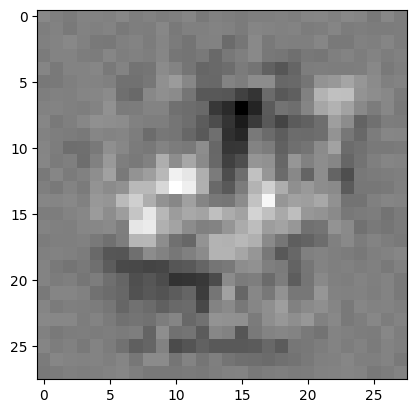

Epoch[17/100], loss: 0.102941, acc: 0.992000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


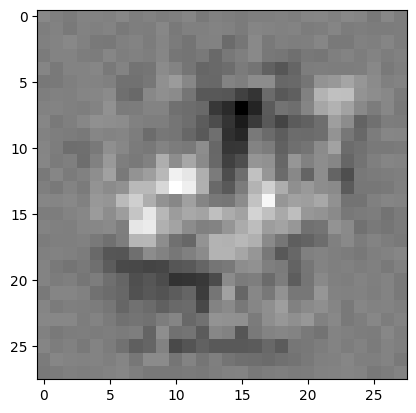

Epoch[18/100], loss: 0.102730, acc: 0.993000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


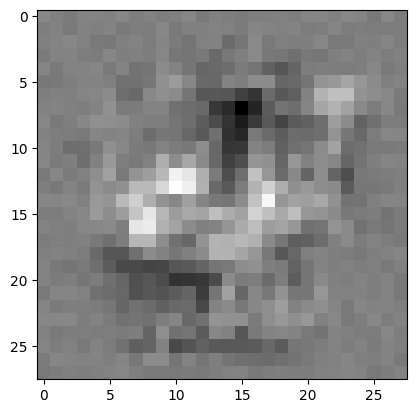

Epoch[19/100], loss: 0.102521, acc: 0.993000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


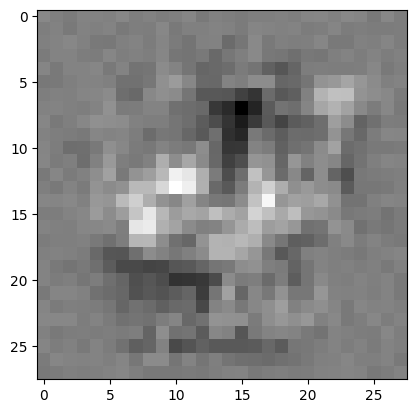

Epoch[20/100], loss: 0.102312, acc: 0.993000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


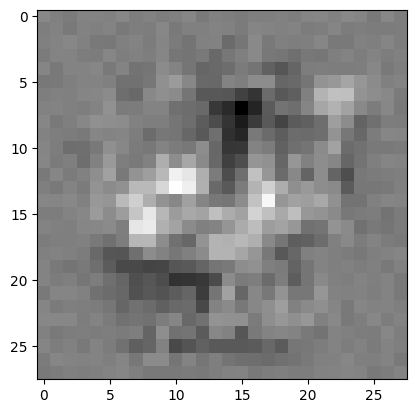

Epoch[21/100], loss: 0.102103, acc: 0.994000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


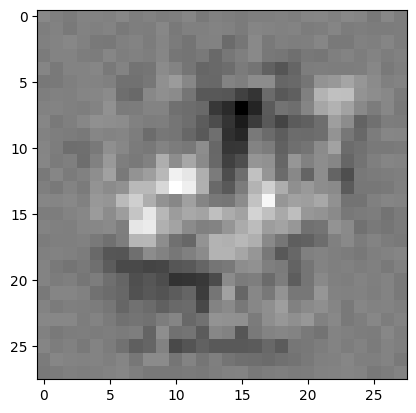

Epoch[22/100], loss: 0.101896, acc: 0.994000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


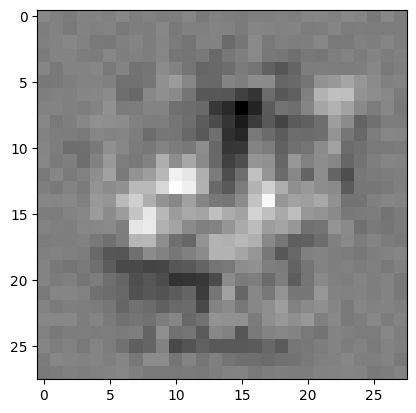

Epoch[23/100], loss: 0.101689, acc: 0.994000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


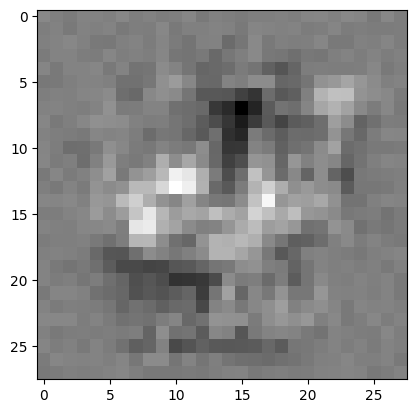

Epoch[24/100], loss: 0.101483, acc: 0.994000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


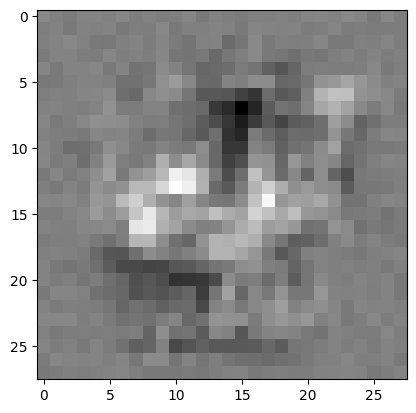

Epoch[25/100], loss: 0.101278, acc: 0.994000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


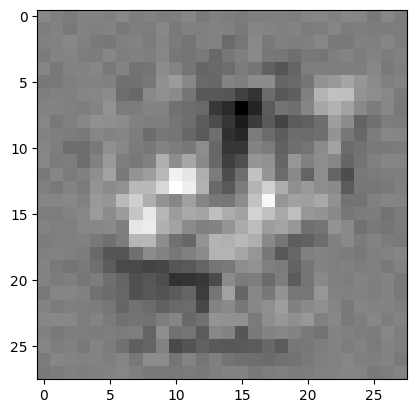

Epoch[26/100], loss: 0.101074, acc: 0.994000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


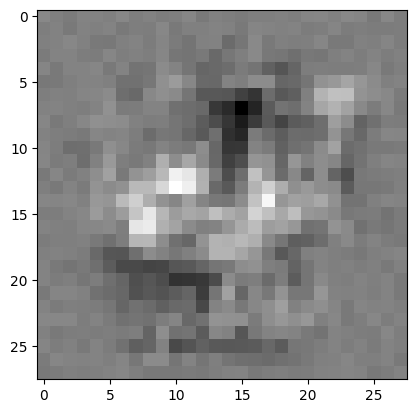

Epoch[27/100], loss: 0.100870, acc: 0.994000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


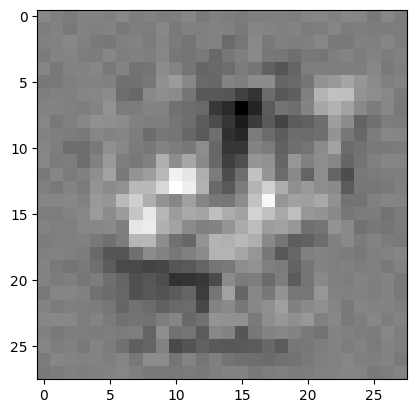

Epoch[28/100], loss: 0.100667, acc: 0.994000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


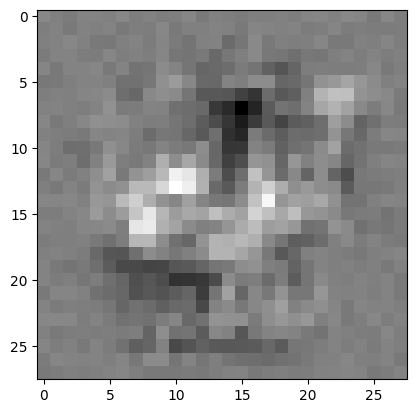

Epoch[29/100], loss: 0.100465, acc: 0.994000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


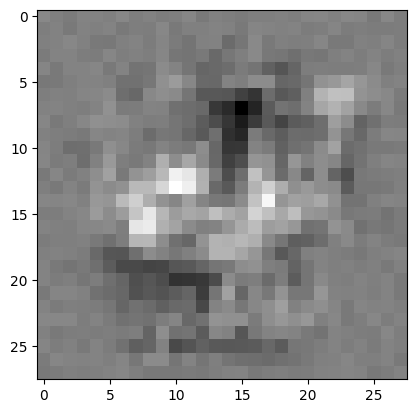

Epoch[30/100], loss: 0.100263, acc: 0.994000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


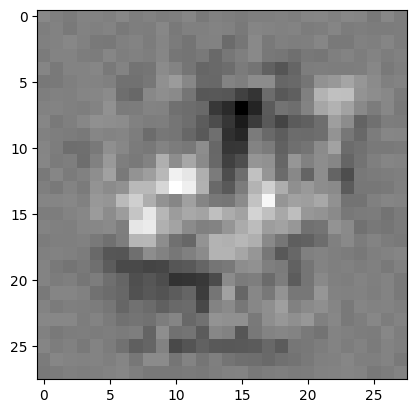

Epoch[31/100], loss: 0.100063, acc: 0.994000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


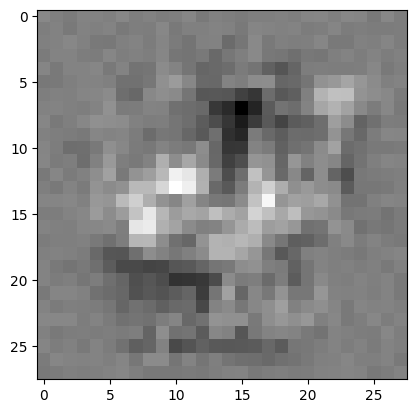

Epoch[32/100], loss: 0.099863, acc: 0.994000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


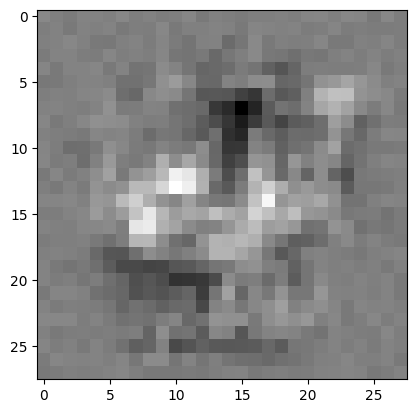

Epoch[33/100], loss: 0.099663, acc: 0.994000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


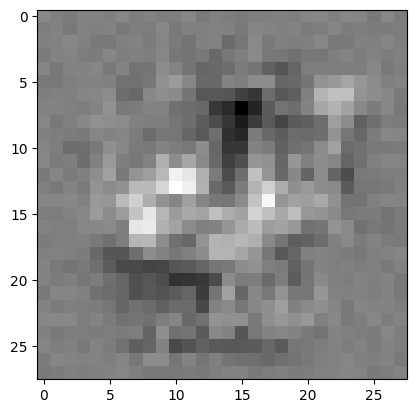

Epoch[34/100], loss: 0.099465, acc: 0.994000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


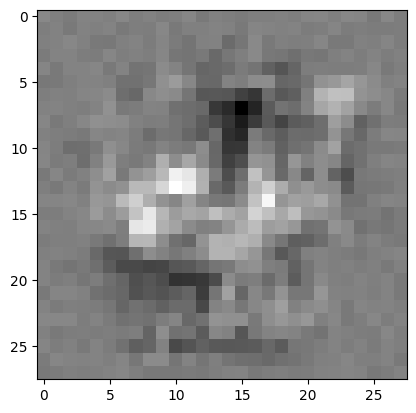

Epoch[35/100], loss: 0.099267, acc: 0.994000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


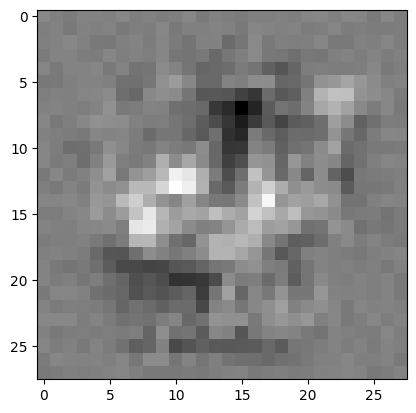

Epoch[36/100], loss: 0.099070, acc: 0.994000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


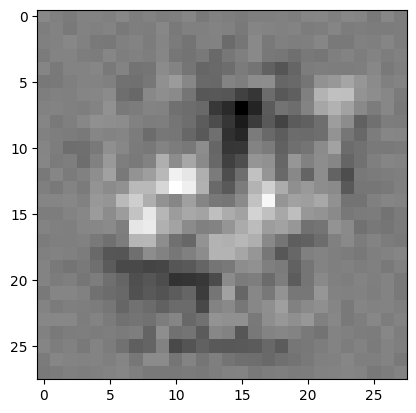

Epoch[37/100], loss: 0.098873, acc: 0.994000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


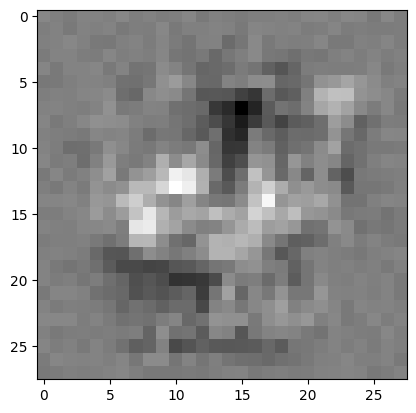

Epoch[38/100], loss: 0.098677, acc: 0.994000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


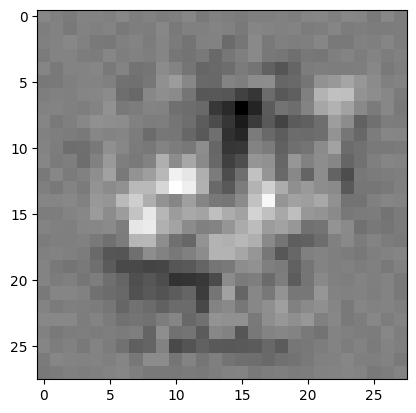

Epoch[39/100], loss: 0.098482, acc: 0.994000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


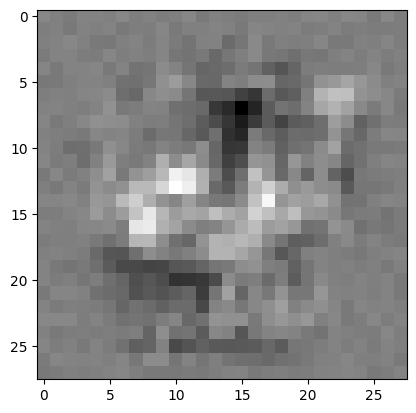

Epoch[40/100], loss: 0.098288, acc: 0.994000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


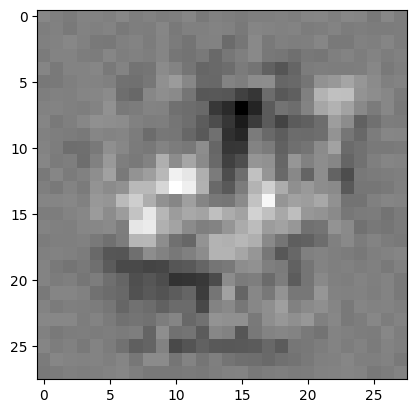

Epoch[41/100], loss: 0.098094, acc: 0.994000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


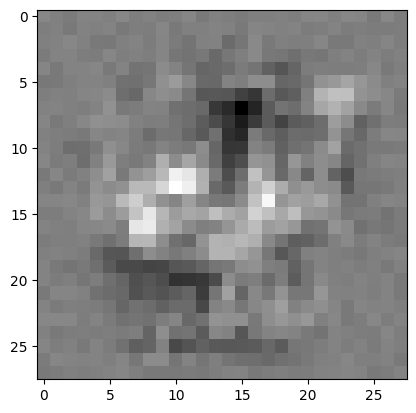

Epoch[42/100], loss: 0.097901, acc: 0.994000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


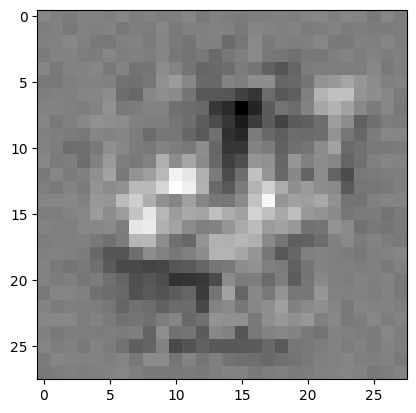

Epoch[43/100], loss: 0.097709, acc: 0.994000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


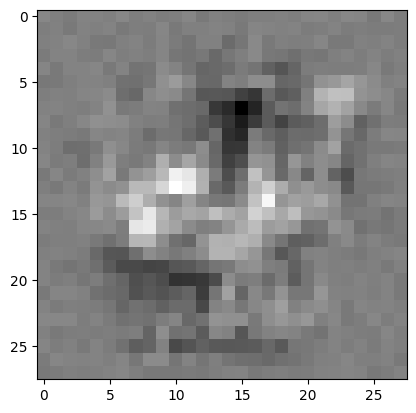

Epoch[44/100], loss: 0.097518, acc: 0.994000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


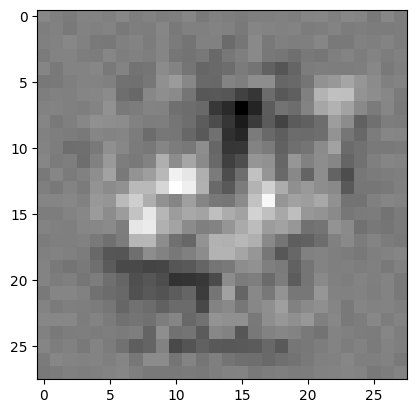

Epoch[45/100], loss: 0.097327, acc: 0.994000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


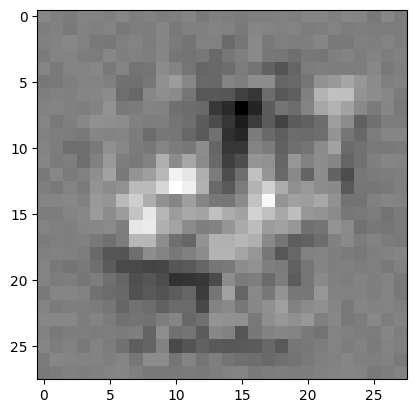

Epoch[46/100], loss: 0.097137, acc: 0.994000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


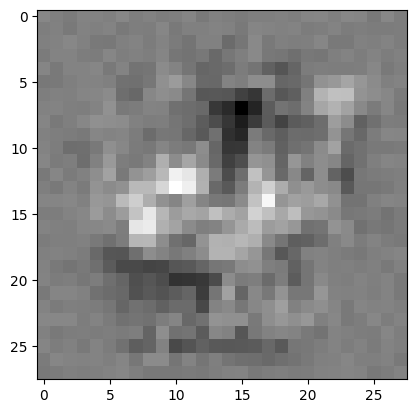

Epoch[47/100], loss: 0.096947, acc: 0.994000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


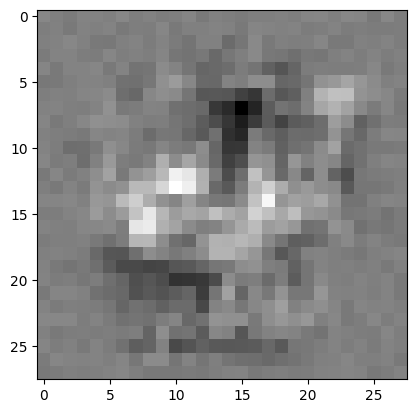

Epoch[48/100], loss: 0.096758, acc: 0.994000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


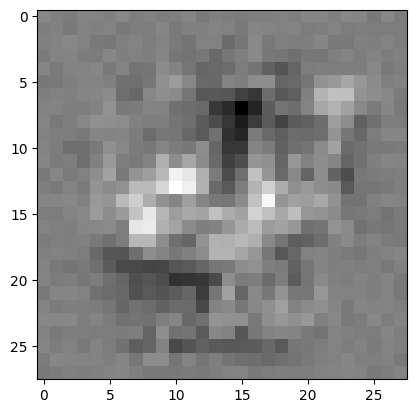

Epoch[49/100], loss: 0.096570, acc: 0.994000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


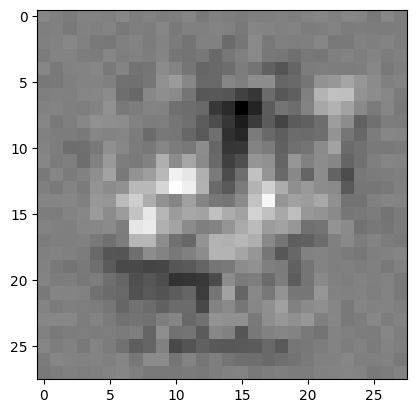

Epoch[50/100], loss: 0.096382, acc: 0.994000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


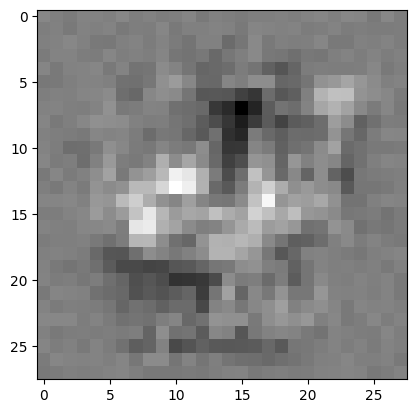

Epoch[51/100], loss: 0.096195, acc: 0.994000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


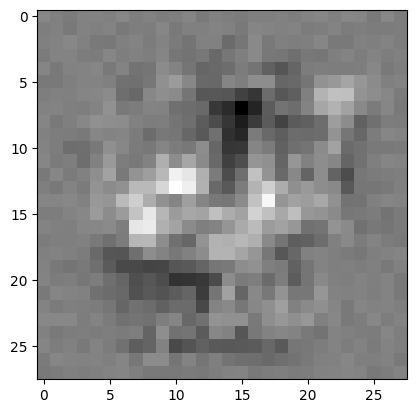

Epoch[52/100], loss: 0.096009, acc: 0.994000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


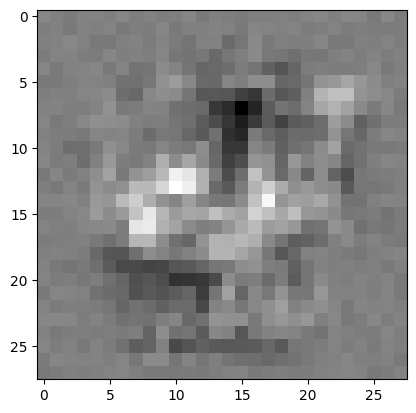

Epoch[53/100], loss: 0.095824, acc: 0.994000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


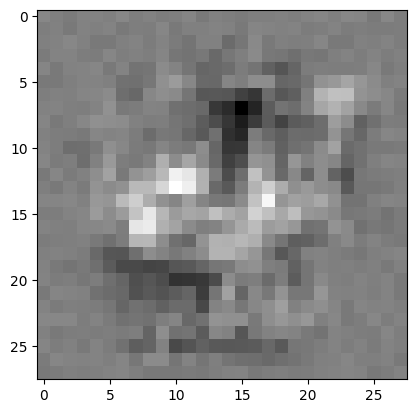

Epoch[54/100], loss: 0.095639, acc: 0.994000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


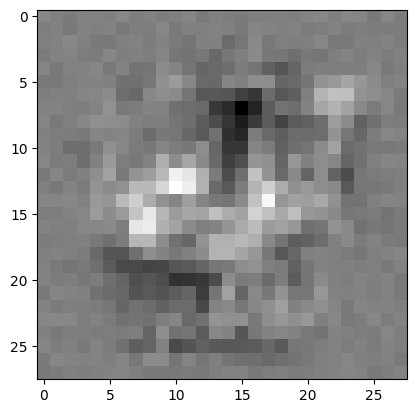

Epoch[55/100], loss: 0.095454, acc: 0.994000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


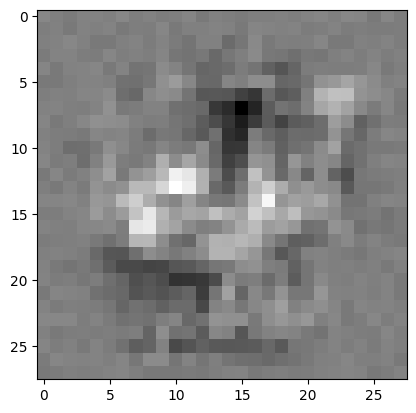

Epoch[56/100], loss: 0.095271, acc: 0.994000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


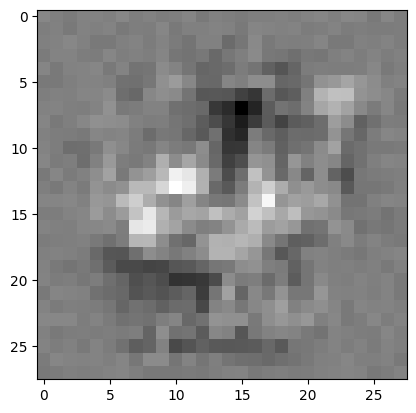

Epoch[57/100], loss: 0.095088, acc: 0.994000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


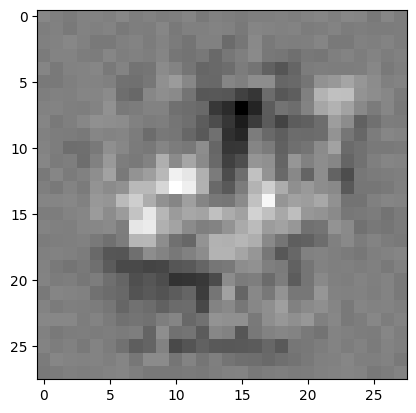

Epoch[58/100], loss: 0.094905, acc: 0.994000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


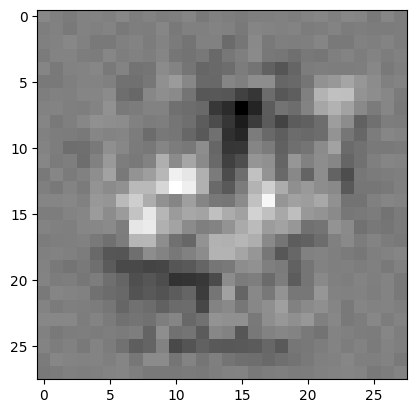

Epoch[59/100], loss: 0.094724, acc: 0.994000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


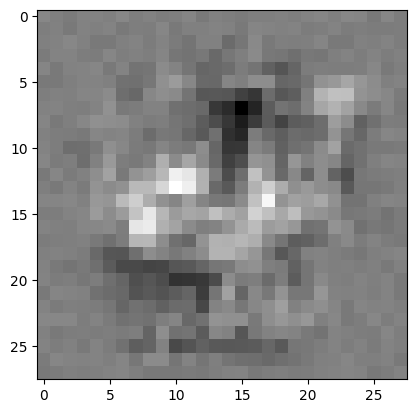

Epoch[60/100], loss: 0.094543, acc: 0.994000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


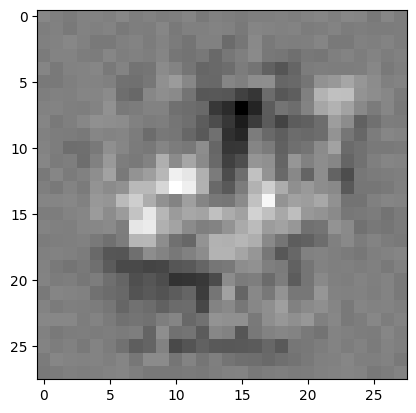

Epoch[61/100], loss: 0.094362, acc: 0.994000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


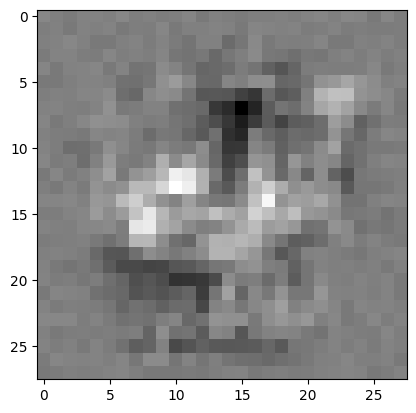

Epoch[62/100], loss: 0.094182, acc: 0.994000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


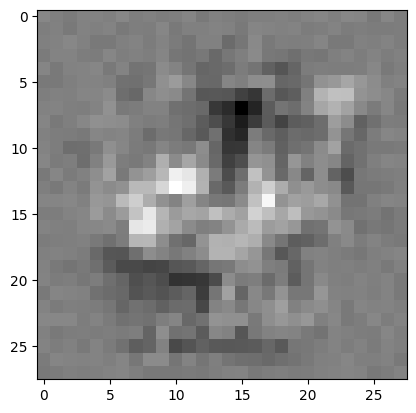

Epoch[63/100], loss: 0.094003, acc: 0.994000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


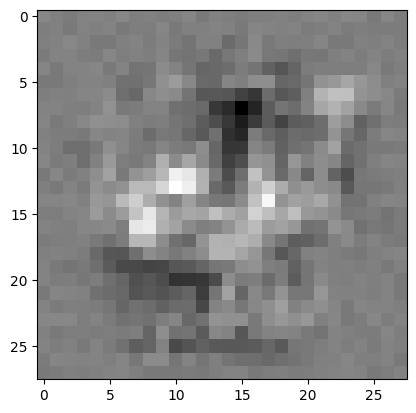

Epoch[64/100], loss: 0.093825, acc: 0.994000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


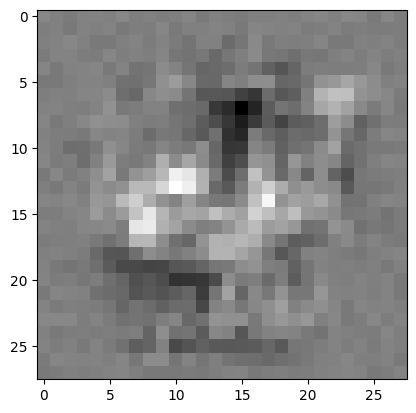

Epoch[65/100], loss: 0.093647, acc: 0.994000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


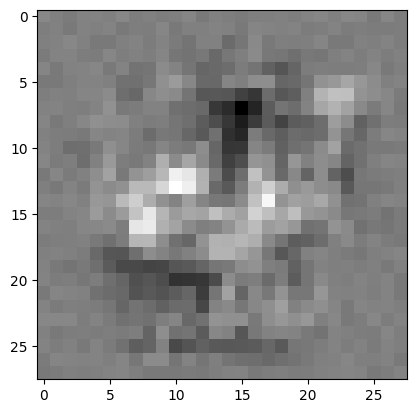

Epoch[66/100], loss: 0.093469, acc: 0.994000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


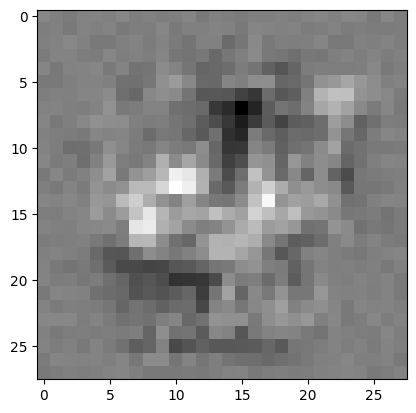

Epoch[67/100], loss: 0.093293, acc: 0.994000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


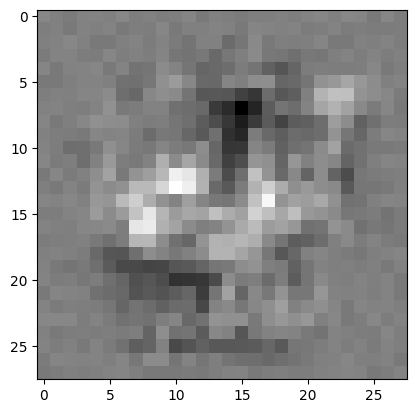

Epoch[68/100], loss: 0.093116, acc: 0.994000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


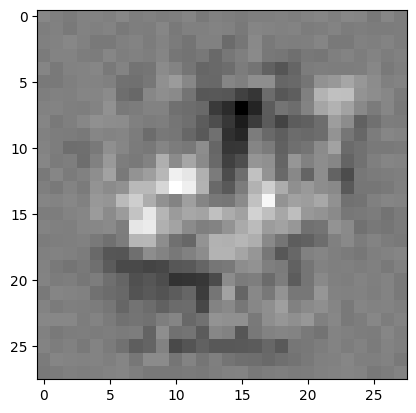

Epoch[69/100], loss: 0.092941, acc: 0.995000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


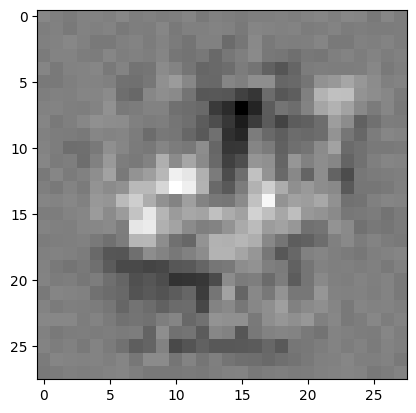

Epoch[70/100], loss: 0.092766, acc: 0.995000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


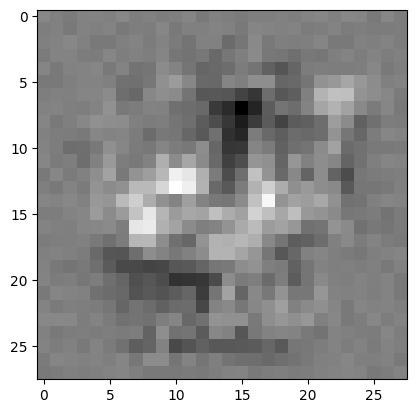

Epoch[71/100], loss: 0.092592, acc: 0.995000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


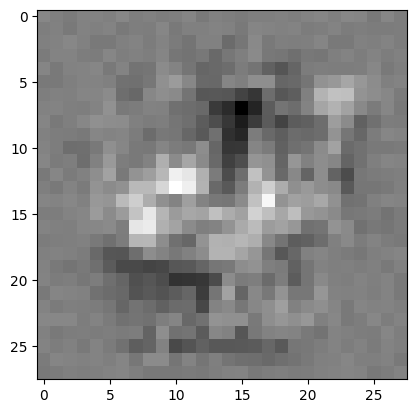

Epoch[72/100], loss: 0.092418, acc: 0.995000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


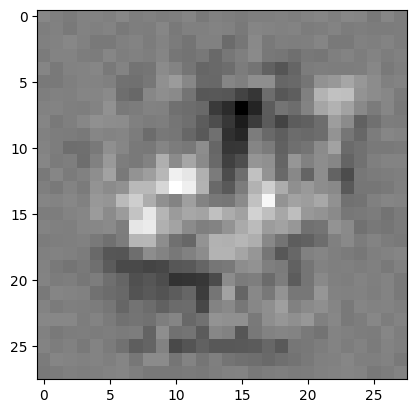

Epoch[73/100], loss: 0.092245, acc: 0.995000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


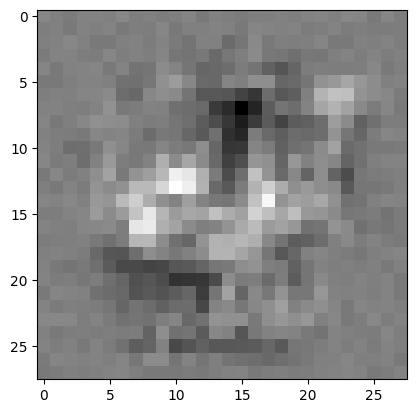

Epoch[74/100], loss: 0.092072, acc: 0.995000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


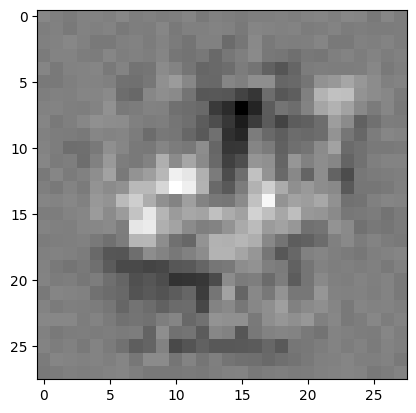

Epoch[75/100], loss: 0.091900, acc: 0.995000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


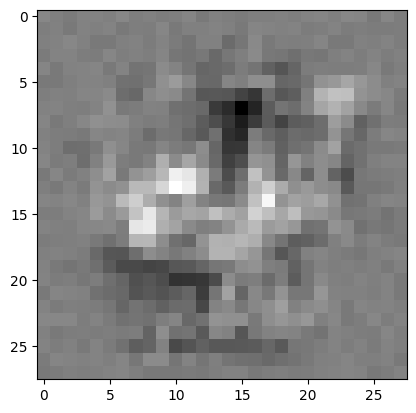

Epoch[76/100], loss: 0.091729, acc: 0.995000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


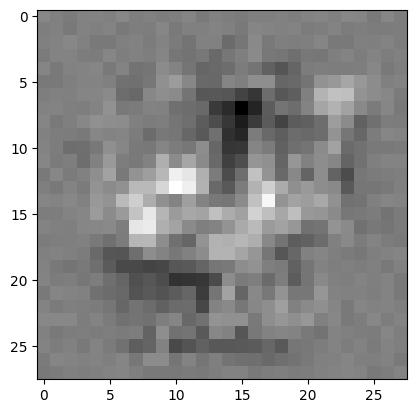

Epoch[77/100], loss: 0.091558, acc: 0.995000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


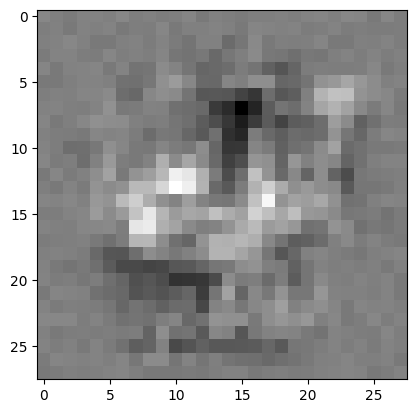

Epoch[78/100], loss: 0.091388, acc: 0.995000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


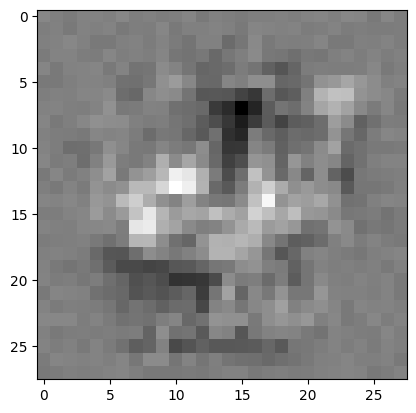

Epoch[79/100], loss: 0.091218, acc: 0.995000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


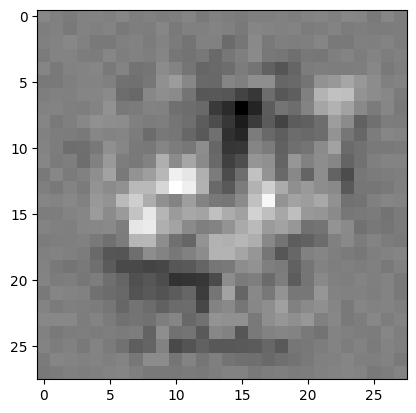

Epoch[80/100], loss: 0.091049, acc: 0.995000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


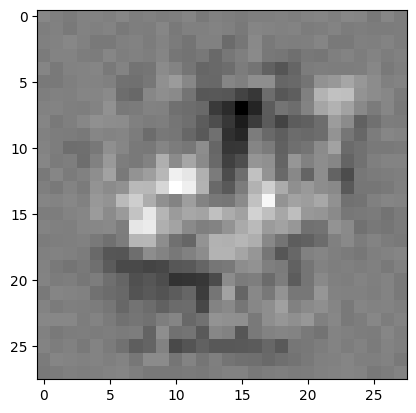

Epoch[81/100], loss: 0.090881, acc: 0.995000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


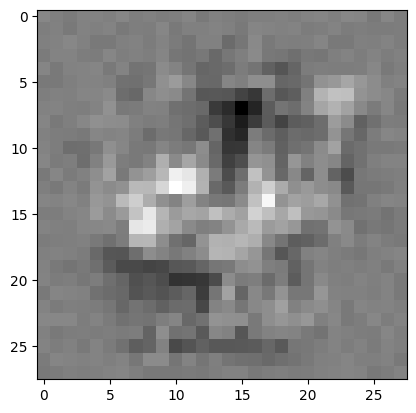

Epoch[82/100], loss: 0.090713, acc: 0.995000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


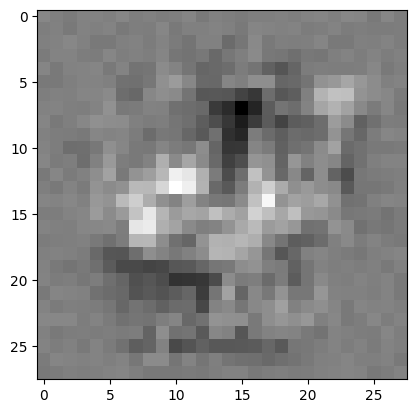

Epoch[83/100], loss: 0.090545, acc: 0.995000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


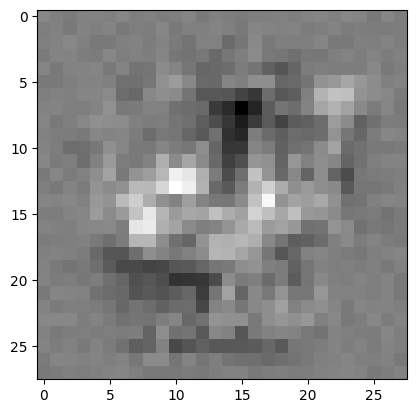

Epoch[84/100], loss: 0.090379, acc: 0.995000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


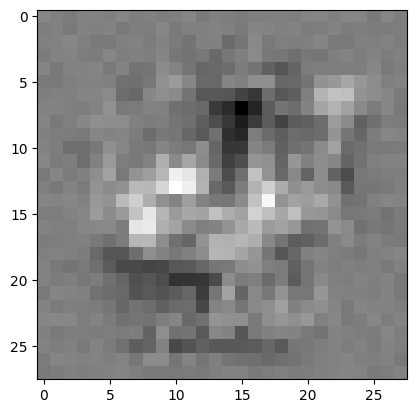

Epoch[85/100], loss: 0.090212, acc: 0.995000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


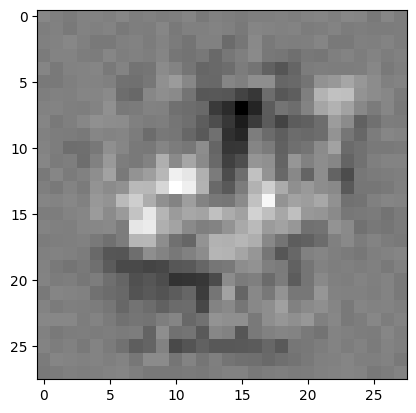

Epoch[86/100], loss: 0.090047, acc: 0.995000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


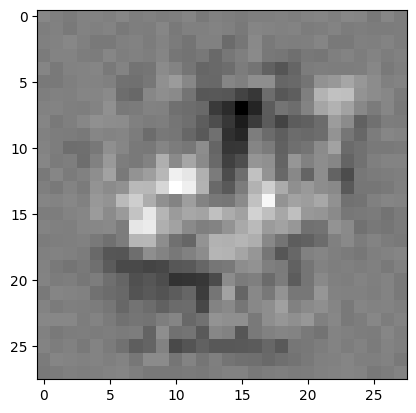

Epoch[87/100], loss: 0.089882, acc: 0.995000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


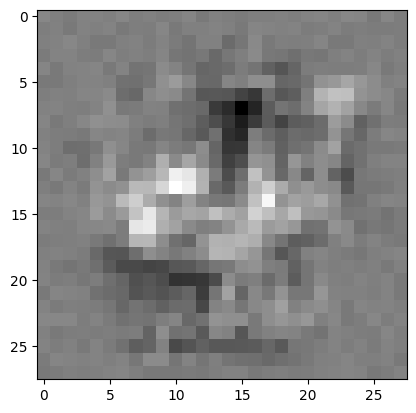

Epoch[88/100], loss: 0.089717, acc: 0.995000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


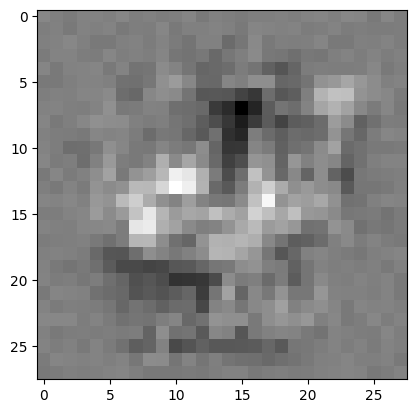

Epoch[89/100], loss: 0.089553, acc: 0.995000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


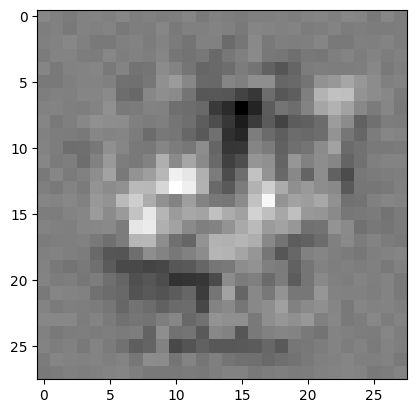

Epoch[90/100], loss: 0.089390, acc: 0.995000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


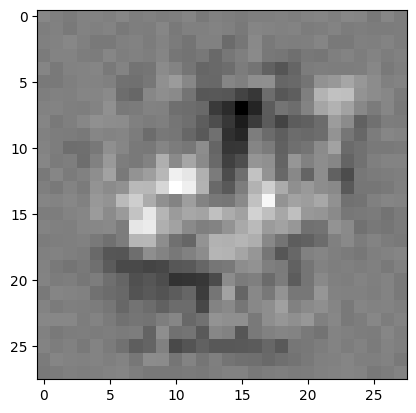

Epoch[91/100], loss: 0.089227, acc: 0.995000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


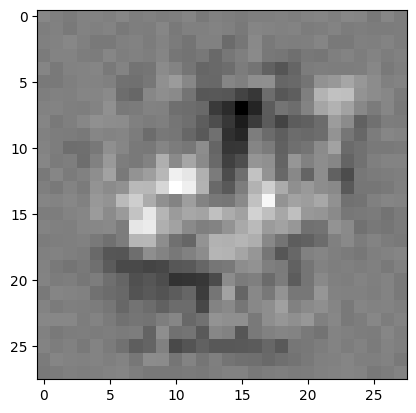

Epoch[92/100], loss: 0.089064, acc: 0.995000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


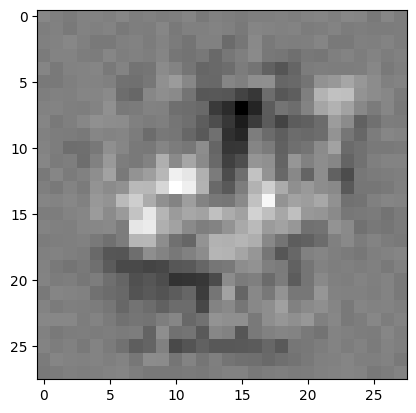

Epoch[93/100], loss: 0.088903, acc: 0.995000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


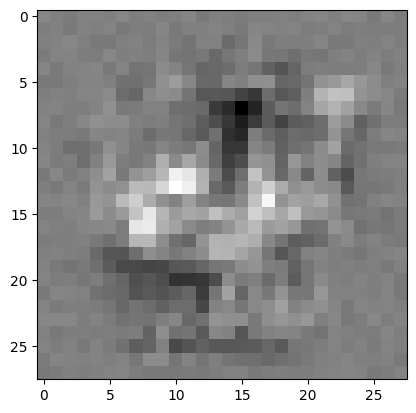

Epoch[94/100], loss: 0.088741, acc: 0.995000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


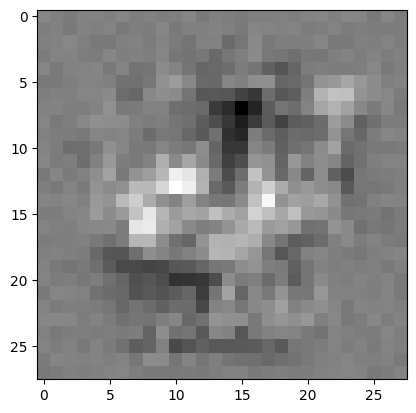

Epoch[95/100], loss: 0.088581, acc: 0.995000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


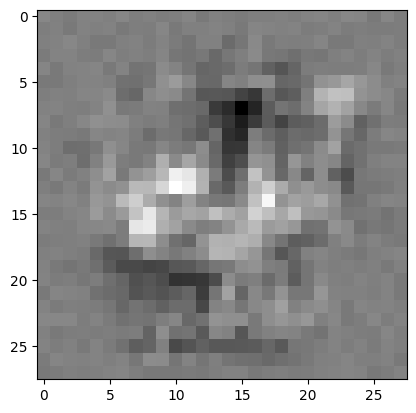

Epoch[96/100], loss: 0.088420, acc: 0.995000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


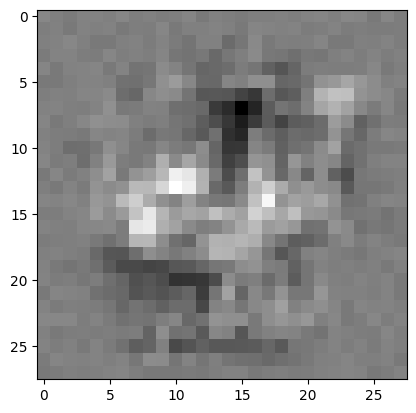

Epoch[97/100], loss: 0.088261, acc: 0.995000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


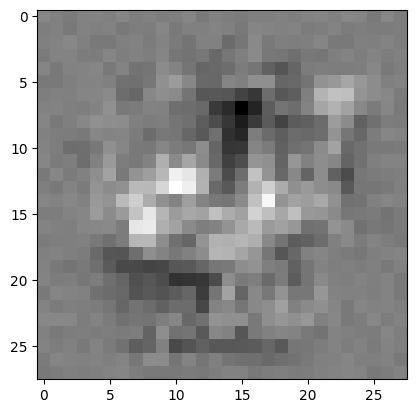

Epoch[98/100], loss: 0.088102, acc: 0.995000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


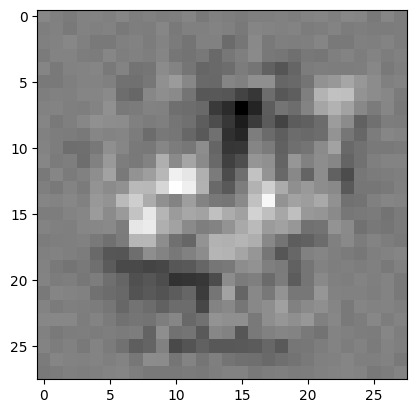

Epoch[99/100], loss: 0.087943, acc: 0.995000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


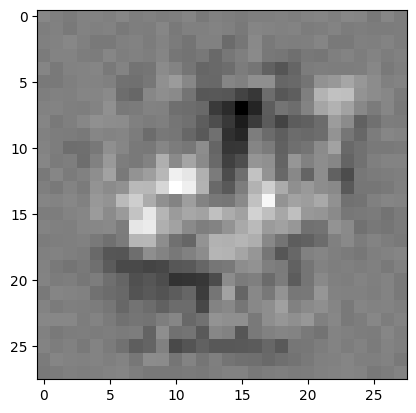

Epoch[100/100], loss: 0.087785, acc: 0.995000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


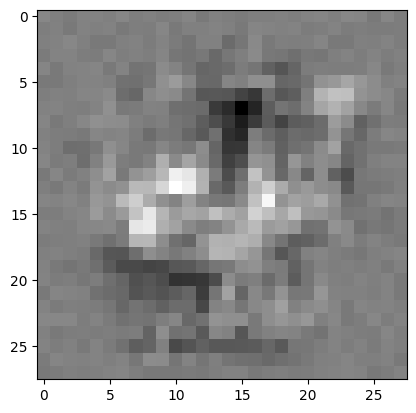

In [27]:
losses = []
import numpy

import numpy
zs = []

for i in range(epochs):
    # Transforma a entrada para uma dimensão
    inputs = Variable(x_train.view(-1, 28 * 28))
    # Predict da rede
    outputs = model(inputs)

    # z0 a z9
    zs.append(outputs[1].detach().numpy())

    # calcula a perda
    loss = criterion(outputs, Variable(y_train))

    # zero, backpropagation, ajusta parâmetros pelo gradiente descendente
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    losses.append(loss.item())

    _, predicts = torch.max(outputs, 1)

    y_pred = predicts.data
    accuracy = (y_pred.numpy() == y_train.numpy()).mean()

    print('Epoch[{}/{}], loss: {:.6f}, acc: {:.6f}'
              .format(i+1, epochs, loss.data, accuracy))

    weights = model.state_dict()['weight']
    print('weights:', weights.shape)

    bias = model.state_dict()['bias']
    print('bias:   ', bias.shape)

    # Visualizando pesos da classe 3
    plt.imshow(weights[4, :].numpy().reshape((28,28)),cmap = 'gray')
    plt.show()

## Perguntas

1. Qual é o shape da matriz de entrada na rede? R: [1, 784]
2. Qual é o shape da saída da rede? R: [1, 10]
3. Qual é o número total de parâmetros da rede, incluindo o bias? R: 7840 parâmentros + 10 bias = 7850 parâmentros

# Aprendizados


Aqui está o texto para a célula Aprendizados:

Aprendizados
Neste experimento, aplicamos a Regressão Logística (Softmax) ao dataset MNIST para classificação de dígitos manuscritos. Os principais aprendizados foram:

- Imagens como vetores: cada imagem de 28×28 pixels foi transformada em um vetor de 784 atributos com .view(-1, 28*28), permitindo que a rede linear processe imagens como se fossem vetores de entrada.
- Escala dos dados: os pixels foram normalizados para o intervalo [0, 1] dividindo por 255, o que facilita a convergência do treinamento.
- Modelo com muitos parâmetros: a rede nn.Linear(784, 10) possui 784×10 = 7.840 pesos + 10 bias = 7.850 parâmetros no total — muito mais do que no exemplo da Íris, refletindo a maior complexidade dos dados.
- Interpretação visual dos pesos: ao reshapear os pesos de cada neurônio de saída para 28×28, é possível visualizar o que a rede aprendeu para cada classe — os pesos formam imagens que lembram os próprios dígitos, mostrando quais regiões dos pixels são mais importantes para cada classificação.
- Validação separada: o uso de um conjunto de validação com torch.no_grad() permite monitorar se o modelo está generalizando ou apenas memorizando os dados de treinamento (overfitting).
- Evolução dos pesos: visualizar os pesos da classe 4 a cada época mostrou como a rede vai gradualmente aprendendo a representação do dígito ao longo do treinamento.